In [1]:
!pip install pytorch-msssim scikit-learn tqdm --quiet
print("✅ Instalado")

✅ Instalado


In [2]:
import os, json, time, gc, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

Device: cuda
GPU: NVIDIA H200


In [3]:
DATASET_PATH = "/workspace/Preprocess/latent_space_outputs/dataset_final_estructuras.npz"

data = np.load(DATASET_PATH, allow_pickle=True)
imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)
print(f"imgs {imgs.shape} | params {params.shape}")

X_tr, X_tmp, y_tr, y_tmp = train_test_split(imgs, params, test_size=0.30, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)

scaler = MinMaxScaler().fit(y_tr)
y_tr_s  = scaler.transform(y_tr).astype(np.float32)
y_val_s = scaler.transform(y_val).astype(np.float32)
y_te_s  = scaler.transform(y_te).astype(np.float32)

COND_DIM = 8; IMG_RAW = 39; IMG_SIZE = 40

class SpinesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).permute(0, 3, 1, 2).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        img = F.pad(self.X[i], (0, 1, 0, 1), mode="reflect")
        return img, self.y[i]

train_ds = SpinesDataset(X_tr, y_tr_s)
val_ds   = SpinesDataset(X_val, y_val_s)
test_ds  = SpinesDataset(X_te, y_te_s)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"train {len(train_ds)} | val {len(val_ds)} | batches/época {len(train_loader)}")

imgs (166141, 39, 39, 1) | params (166141, 8)
train 116298 | val 24921 | batches/época 227


In [4]:
class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_ab = torch.sqrt(self.alpha_bars)
        self.sqrt_1mab = torch.sqrt(1.0 - self.alpha_bars)
    def add_noise(self, x0, t, noise):
        sab = self.sqrt_ab[t].view(-1, 1, 1, 1)
        s1mab = self.sqrt_1mab[t].view(-1, 1, 1, 1)
        return sab * x0 + s1mab * noise

scheduler = DDPMScheduler(T=1000, device=device)

# funciones físicas (para validación C(r), S(k))
def build_radial_matrix(H, W, device):
    cy, cx = H // 2, W // 2
    Y, X = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    R = torch.sqrt((X - cx).float()**2 + (Y - cy).float()**2).round().long().flatten()
    n_bins = int(R.max().item()) + 1
    M = torch.zeros(n_bins, H*W)
    for b in range(n_bins):
        mask = (R == b).float(); M[b] = mask / mask.sum().clamp(min=1)
    return M.to(device)

_RADIAL_M = {}
def radial_profile(power_2d):
    B, H, W = power_2d.shape
    key = (H, W, power_2d.device)
    if key not in _RADIAL_M:
        _RADIAL_M[key] = build_radial_matrix(H, W, power_2d.device)
    return power_2d.reshape(B, H*W) @ _RADIAL_M[key].T

def structure_factor(img):
    x = img[:, 0]
    F_img = torch.fft.fftshift(torch.fft.fft2(x.float()), dim=(-2, -1))
    return F_img.real**2 + F_img.imag**2

def correlation_map(img):
    x = img[:, 0].float()
    Fx = torch.fft.fft2(x)
    corr = torch.fft.ifft2(Fx * torch.conj(Fx)).real
    return torch.fft.fftshift(corr, dim=(-2, -1)) / (x.shape[-1]*x.shape[-2])

print(f"✅ Scheduler DDPM (T={scheduler.T}) + funciones físicas listas")

✅ Scheduler DDPM (T=1000) + funciones físicas listas


In [5]:
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class FiLMResBlock(nn.Module):
    """Residual con FiLM: el tiempo se suma, la condición θ modula (γ,β) por canal."""
    def __init__(self, in_ch, out_ch, time_dim, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.film = nn.Linear(cond_dim, 2 * out_ch)     # genera γ y β
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, c_emb):
        h = self.conv1(x)
        h = self.norm1(h) + self.time_proj(t_emb)[:, :, None, None]    # tiempo por suma
        gamma, beta = self.film(c_emb).chunk(2, dim=1)
        h = gamma[:, :, None, None] * h + beta[:, :, None, None]       # FiLM: γ·h + β
        h = F.silu(h)
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)

class UNetFiLM(nn.Module):
    def __init__(self, cond_dim=8, base_ch=64, emb_dim=256):
        super().__init__()
        self.emb_dim = emb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.in_conv = nn.Conv2d(1, base_ch, 3, padding=1)
        self.down1 = FiLMResBlock(base_ch, base_ch, emb_dim, emb_dim)
        self.down2 = FiLMResBlock(base_ch, base_ch*2, emb_dim, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.mid = FiLMResBlock(base_ch*2, base_ch*2, emb_dim, emb_dim)
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.up1 = FiLMResBlock(base_ch*2 + base_ch*2, base_ch, emb_dim, emb_dim)
        self.up2 = FiLMResBlock(base_ch + base_ch, base_ch, emb_dim, emb_dim)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t, cond):
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.emb_dim))
        c_emb = self.cond_mlp(cond)
        x  = self.in_conv(x)
        d1 = self.down1(x, t_emb, c_emb)
        d2 = self.down2(self.pool(d1), t_emb, c_emb)
        m  = self.mid(d2, t_emb, c_emb)
        u  = self.up1(torch.cat([m, d2], 1), t_emb, c_emb)
        u  = self.up(u)
        u  = self.up2(torch.cat([u, d1], 1), t_emb, c_emb)
        return self.out_conv(u)

_m = UNetFiLM(cond_dim=8).to(device)
print(f"✅ U-Net FiLM | {sum(p.numel() for p in _m.parameters()):,} parámetros")
_x, _y = next(iter(train_loader))
_t = torch.randint(0, 1000, (_x.size(0),), device=device)
print(f"output {_m(_x.to(device), _t, _y.to(device)).shape}  (esperado [B,1,40,40])")
del _m

✅ U-Net FiLM | 1,466,753 parámetros
output torch.Size([512, 1, 40, 40])  (esperado [B,1,40,40])


In [6]:
def ddpm_loss(model, x0, cond, scheduler):
    B = x0.size(0)
    t = torch.randint(0, scheduler.T, (B,), device=x0.device)
    noise = torch.randn_like(x0)
    x_t = scheduler.add_noise(x0, t, noise)
    return F.mse_loss(model(x_t, t, cond), noise)

_model = UNetFiLM(cond_dim=8).to(device)
_opt = torch.optim.Adam(_model.parameters(), lr=2e-4)
_scaler = torch.amp.GradScaler('cuda')
t0 = time.time(); _model.train()
for i, (x, y) in enumerate(train_loader):
    x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
    _opt.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda'):
        loss = ddpm_loss(_model, x, y, scheduler)
    _scaler.scale(loss).backward(); _scaler.step(_opt); _scaler.update()
    if i >= 20: break
dt = (time.time()-t0)/21
print(f"~{dt*1000:.0f} ms/batch → ~{dt*len(train_loader):.1f}s/época → "
      f"~{dt*len(train_loader)*100/60:.1f} min para 100 épocas")
del _model, _opt, _scaler; gc.collect(); torch.cuda.empty_cache()

~188 ms/batch → ~42.7s/época → ~71.2 min para 100 épocas


In [7]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1-self.decay)
            else:
                self.shadow[k] = v.detach().clone()

EPOCHS = 100
LR = 2e-4

model = UNetFiLM(cond_dim=8).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler_amp = torch.amp.GradScaler('cuda')
ema = EMA(model, decay=0.999)
history = {"train": [], "val": []}

t_start = time.time()
epoch_bar = tqdm(range(EPOCHS), desc="Training FiLM", unit="ep")
for epoch in epoch_bar:
    model.train(); tr_loss = tr_n = 0
    batch_bar = tqdm(train_loader, desc=f"  E{epoch}", leave=False, unit="b")
    for x, y in batch_bar:
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            loss = ddpm_loss(model, x, y, scheduler)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(opt); scaler_amp.update()
        ema.update(model)
        tr_loss += loss.item()*x.size(0); tr_n += x.size(0)
        batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    sched.step()

    model.eval(); v_loss = v_n = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                v_loss += ddpm_loss(model, x, y, scheduler).item()*x.size(0)
            v_n += x.size(0)

    tr = tr_loss/tr_n; vl = v_loss/v_n
    history["train"].append(tr); history["val"].append(vl)
    epoch_bar.set_postfix(train=f"{tr:.4f}", val=f"{vl:.4f}",
                          elapsed=f"{(time.time()-t_start)/60:.1f}min")
    if (epoch+1) % 10 == 0:
        os.makedirs("/workspace/Models", exist_ok=True)
        torch.save(model.state_dict(), "/workspace/Models/ddpm_film_8params.pth")
        torch.save(ema.shadow, "/workspace/Models/ddpm_film_8params_ema.pth")

torch.save(model.state_dict(), "/workspace/Models/ddpm_film_8params.pth")
torch.save(ema.shadow, "/workspace/Models/ddpm_film_8params_ema.pth")
print(f"\n✅ Entrenado en {(time.time()-t_start)/60:.1f} min y guardado (modelo + EMA)")

Training FiLM:   0%|          | 0/100 [00:00<?, ?ep/s]

  E0:   0%|          | 0/227 [00:00<?, ?b/s]

  E1:   0%|          | 0/227 [00:00<?, ?b/s]

  E2:   0%|          | 0/227 [00:00<?, ?b/s]

  E3:   0%|          | 0/227 [00:00<?, ?b/s]

...

  E96:   0%|          | 0/227 [00:00<?, ?b/s]

  E97:   0%|          | 0/227 [00:00<?, ?b/s]

  E98:   0%|          | 0/227 [00:00<?, ?b/s]

  E99:   0%|          | 0/227 [00:00<?, ?b/s]


✅ Entrenado en 16.4 min y guardado (modelo + EMA)


Sampling 8 imágenes en 0.3s (DDIM 50 pasos)


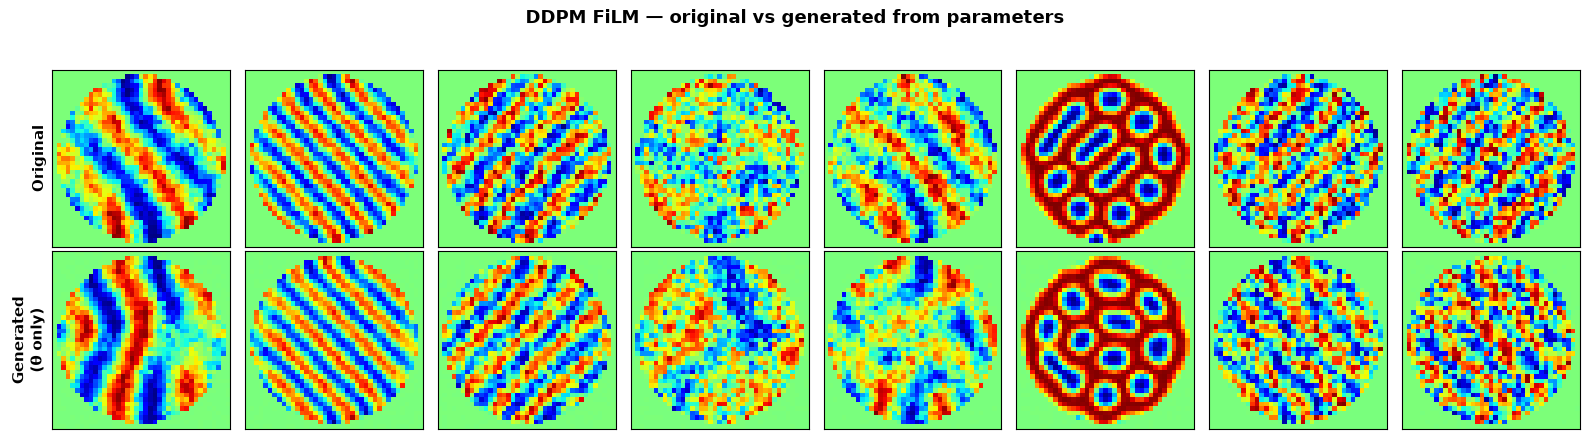

In [8]:
@torch.no_grad()
def sample_ddim(model, cond, scheduler, n_steps=50, eta=0.0):
    model.eval()
    B = cond.size(0)
    step_idx = torch.linspace(0, scheduler.T-1, n_steps, dtype=torch.long).flip(0)
    x = torch.randn(B, 1, IMG_SIZE, IMG_SIZE, device=cond.device)
    with torch.amp.autocast('cuda'):
        for i in range(n_steps):
            t = step_idx[i]
            t_batch = torch.full((B,), t, device=cond.device, dtype=torch.long)
            eps = model(x, t_batch, cond)
            ab_t = scheduler.alpha_bars[t]
            x0 = ((x - torch.sqrt(1-ab_t)*eps) / torch.sqrt(ab_t)).clamp(-1, 1)
            if i < n_steps - 1:
                ab_next = scheduler.alpha_bars[step_idx[i+1]]
                sigma = eta * torch.sqrt((1-ab_next)/(1-ab_t) * (1-ab_t/ab_next))
                x = torch.sqrt(ab_next)*x0 + torch.sqrt(1-ab_next-sigma**2)*eps
                if eta > 0: x = x + sigma*torch.randn_like(x)
            else:
                x = x0
    return x

sample_model = UNetFiLM(cond_dim=8).to(device)
sample_model.load_state_dict(torch.load("/workspace/Models/ddpm_film_8params_ema.pth"))

n_show = 8
xb, yb = next(iter(DataLoader(test_ds, batch_size=n_show, shuffle=True)))
xb, yb = xb.to(device), yb.to(device)
t0 = time.time()
x_gen = sample_ddim(sample_model, yb, scheduler, n_steps=50)
print(f"Sampling {n_show} imágenes en {time.time()-t0:.1f}s (DDIM 50 pasos)")

orig = xb[:, :, :39, :39].float().cpu().numpy()[:, 0]
gen  = x_gen[:, :, :39, :39].float().cpu().numpy()[:, 0]
fig, axes = plt.subplots(2, n_show, figsize=(2.0*n_show, 4.3), facecolor="white")
for c in range(n_show):
    axes[0, c].imshow(orig[c], cmap="jet", vmin=-1, vmax=1)
    axes[1, c].imshow(np.clip(gen[c], -1, 1), cmap="jet", vmin=-1, vmax=1)
    for r in range(2): axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Generated\n(θ only)", fontsize=11, fontweight="bold")
plt.suptitle("DDPM FiLM — original vs generated from parameters",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/workspace/Process/Images/ddpm_film_samples.pdf", bbox_inches="tight", facecolor="white")
plt.show()

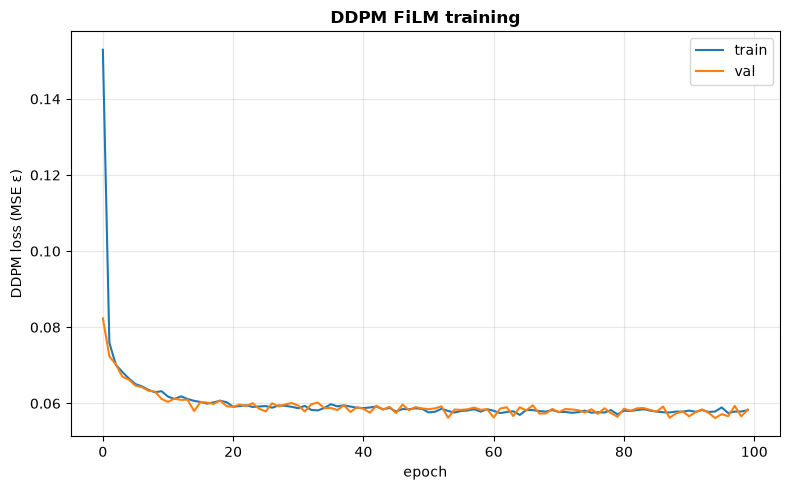

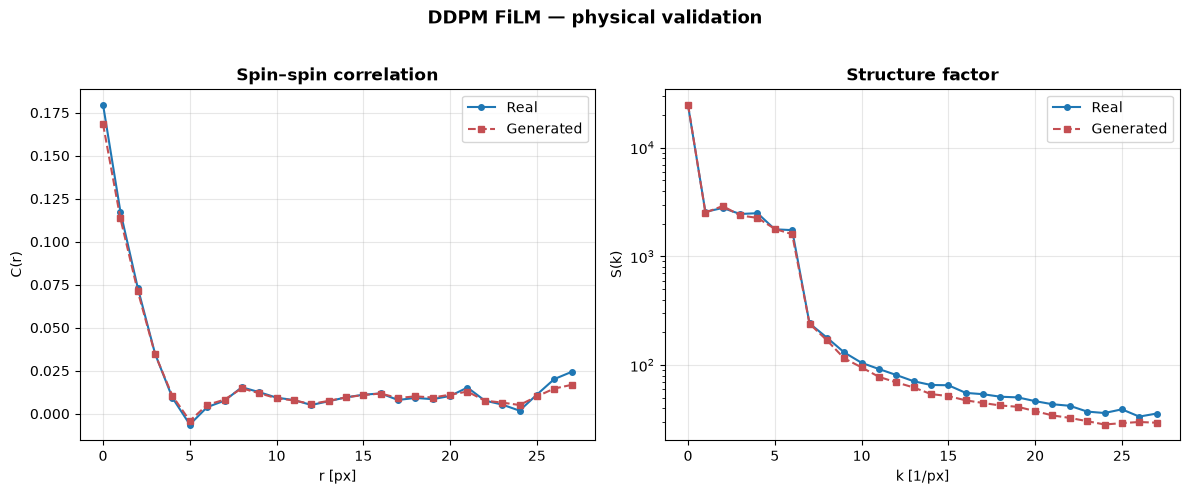

C(r) MAE:  0.0018
S(k) MAE (log): 0.1408


In [9]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.plot(history["train"], label="train"); ax.plot(history["val"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("DDPM loss (MSE ε)")
ax.set_title("DDPM FiLM training", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/workspace/Process/Images/ddpm_film_training.pdf", bbox_inches="tight")
plt.show()

xb, yb = next(iter(DataLoader(test_ds, batch_size=128, shuffle=False)))
yb = yb.to(device)
x_gen = sample_ddim(sample_model, yb, scheduler, n_steps=50)
xr = xb[:, :, :39, :39].to(device).float()
xg = x_gen[:, :, :39, :39].float()

c_real = radial_profile(correlation_map(xr)).mean(0).cpu().numpy()
c_gen  = radial_profile(correlation_map(xg)).mean(0).cpu().numpy()
s_real = radial_profile(structure_factor(xr)).mean(0).cpu().numpy()
s_gen  = radial_profile(structure_factor(xg)).mean(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), facecolor="white")
r = np.arange(len(c_real))
axes[0].plot(r, c_real, "o-", color="#1f77b4", label="Real", markersize=4)
axes[0].plot(r, c_gen,  "s--", color="#C44E52", label="Generated", markersize=4)
axes[0].set_xlabel("r [px]"); axes[0].set_ylabel("C(r)")
axes[0].set_title("Spin–spin correlation", fontweight="bold"); axes[0].legend(); axes[0].grid(alpha=0.3)
k = np.arange(len(s_real))
axes[1].semilogy(k, s_real+1, "o-", color="#1f77b4", label="Real", markersize=4)
axes[1].semilogy(k, s_gen+1,  "s--", color="#C44E52", label="Generated", markersize=4)
axes[1].set_xlabel("k [1/px]"); axes[1].set_ylabel("S(k)")
axes[1].set_title("Structure factor", fontweight="bold"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("DDPM FiLM — physical validation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/workspace/Process/Images/ddpm_film_physical.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"C(r) MAE:  {np.abs(c_real - c_gen).mean():.4f}")
print(f"S(k) MAE (log): {np.abs(np.log1p(s_real) - np.log1p(s_gen)).mean():.4f}")